## Settings & imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

PREPROCESSING_METHOD = config["preprocessing_method"] # normalization / logarithm
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
MULTIPLICATION_WEIGHTS = config["multiplication_weights"]
DROPOUT_PROB = config["dropout_prob"]

RESULTS_PATH = config["results_path"]
FIGURES_PATH = config["figures_path"]
MODELS_PATH = config["models_path"]

TARGET_PATH = config["target_path"]

In [3]:
# import numpy as np
# import pandas as pd
# import os
# import torch
# import matplotlib.pyplot as plt
# import string
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
# import sklearn
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import normalize
# import csv

## Loading the data

In [4]:
inds_df = load_target_data(TARGET_PATH, ELEMENTS_TO_KEEP)

## Preprocessing

1. In this case, we skip removal of outer samples - it was only done for training examples to ensure the quality of training dataset. No need to do it on target dataset.

2. We skip removing columns from outside ELEMENTS_TO_KEEP list, as we have already done it during dataset loading.

3. There is no missing data in target dataset, so there is no need to remove anything.

In [5]:
inds_df.dropna().shape == inds_df.shape

True

4. For Konstytucja_indicators, we do the same preprocessing as for the training dataset (-> notebooks/inks_nn_regression.ipynb). First, we set negative numbers to zero.

In [6]:
inds_df = set_negative_to_zero_v2(inds_df, ELEMENTS_TO_KEEP)

5. We multiply values by weights.

In [7]:
inds_df = multiply_by_weights_v2(inds_df, ELEMENTS_TO_KEEP, weights=MULTIPLICATION_WEIGHTS)

6. We normalize to Fe.

In [8]:
#inds_df = normalize_to_Fe_v2(inds_df, ELEMENTS_TO_KEEP)

7. Finally, let's reset the index.

In [9]:
inds_df.reset_index(drop=True, inplace=True)

### Converting to np.array

(Everything except Sample_id column.)

In [10]:
X = np.array(inds_df[ELEMENTS_TO_KEEP].values)

### Normalizing / taking logarithm

In [11]:
X = transform_data(X, PREPROCESSING_METHOD)

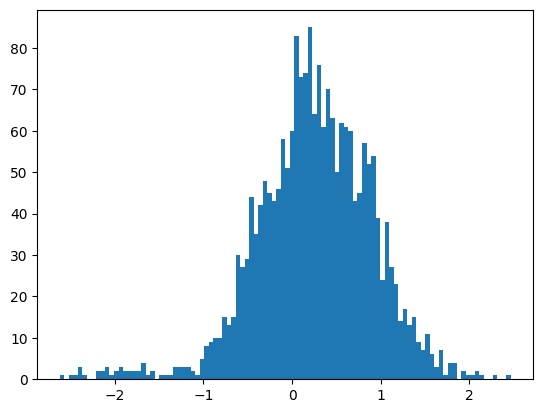

In [12]:
coor = 0
plt.hist(X[:,coor], bins=100);

### Converting to tensors

In [13]:
device = get_device()

Using cuda device


In [14]:
X = data_to_device(X, device)

## Loading the trained model

In [15]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
model.load_state_dict(torch.load(MODELS_PATH))

/tmp/ipykernel_9817/2341782259.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODELS_PATH))


<All keys matched successfully>

## Prediction

In [16]:
model.eval()
prediction = model(X)

## Saving result to a file

In [17]:
model_name = MODELS_PATH.split('/')[-1]
save_prediction(prediction, RESULTS_PATH, model_name)